In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, coalesce

# 1. Khởi động PySpark
spark = SparkSession.builder \
    .appName("Tong_Hop_Data") \
    .config("spark.driver.memory", "16g") \
    .getOrCreate()

spark.conf.set("spark.sql.caseSensitive", "true")

print("Đã khởi động Spark")

# Kiểm tra đường dẫn
base_path = "/content/drive/MyDrive/MiningMassiveData/crawl_amazon_metadata/metadata/"

if os.path.exists(base_path):
    print("Danh sách file thực tế trong thư mục:", os.listdir(base_path))
else:
    print(f"CẢNH BÁO: Đường dẫn {base_path} không tồn tại!")

# ==========================================
# PHÂN XƯỞNG 1: TẠO KHO SẢN PHẨM TỔNG
# ==========================================
print("Đang gom dữ liệu sản phẩm (Metadata)...")

try:
    # Đọc data_small tự cào
    df_scraped = spark.read.json(f"{base_path}*_details.jsonl")

    # Đọc data_small Metadata
    df_meta_elec = spark.read.json(f"{base_path}meta_Electronics.jsonl.gz").drop("details")
    if "asin" not in df_meta_elec.columns and "parent_asin" in df_meta_elec.columns:
        df_meta_elec = df_meta_elec.withColumn("asin", col("parent_asin"))
    elif "asin" in df_meta_elec.columns and "parent_asin" in df_meta_elec.columns:
        df_meta_elec = df_meta_elec.withColumn("asin", coalesce(col("asin"), col("parent_asin")))

    df_meta_phone = spark.read.json(f"{base_path}meta_Cell_Phones_and_Accessories.jsonl.gz").drop("details")
    if "asin" not in df_meta_phone.columns and "parent_asin" in df_meta_phone.columns:
        df_meta_phone = df_meta_phone.withColumn("asin", col("parent_asin"))
    elif "asin" in df_meta_phone.columns and "parent_asin" in df_meta_phone.columns:
        df_meta_phone = df_meta_phone.withColumn("asin", coalesce(col("asin"), col("parent_asin")))

    # Gộp tất cả
    df_meta_tong = df_scraped.unionByName(df_meta_elec, allowMissingColumns=True) \
                             .unionByName(df_meta_phone, allowMissingColumns=True)

    df_san_pham = df_meta_tong.dropna(subset=['asin']).dropDuplicates(['asin'])
    print(f"Tổng số mặt hàng: {df_san_pham.count()} sản phẩm")

    # ==========================================
    # PHÂN XƯỞNG 2: TẠO KHO ĐÁNH GIÁ
    # ==========================================
    print("Đang gom và chắt lọc dữ liệu Review...")
    df_rev_elec = spark.read.json(f"{base_path}Electronics.jsonl.gz")
    df_rev_phone = spark.read.json(f"{base_path}Cell_Phones_and_Accessories.jsonl.gz")

    df_rev_tong = df_rev_elec.unionByName(df_rev_phone, allowMissingColumns=True)
    df_danh_gia = df_rev_tong.join(df_san_pham, on="asin", how="leftsemi")

    print(f"Tổng số lượt review: {df_danh_gia.count()} lượt")

    # ==========================================
    # PHÂN XƯỞNG 3: LƯU KẾT QUẢ
    # ==========================================
    print("Đang lưu dữ liệu...")
    os.makedirs(f"{base_path}output", exist_ok=True)
    df_san_pham.write.mode("overwrite").parquet(f"{base_path}output/san_pham.parquet")
    df_danh_gia.write.mode("overwrite").parquet(f"{base_path}output/danh_gia.parquet")
    print("Hoàn Thành")

except Exception as e:
    print(f"Lỗi khi đọc dữ liệu: {e}")
    print("Vui lòng kiểm tra lại tên file trong Google Drive có khớp chính xác (hoa/thường) không.")

Đã khởi động Spark
Danh sách file thực tế trong thư mục: ['tablets_details.jsonl', 'headphone_details.jsonl', 'laptop_details.jsonl', 'computer_details.jsonl', 'Electronics.jsonl.gz', 'cpu_details_1.jsonl', 'cpu_details_2.jsonl', 'desktop_details.jsonl', 'gpu_details.jsonl', 'monitor_details.jsonl', 'pc_details.jsonl', 'smartphone_details.jsonl', 'Cell_Phones_and_Accessories.jsonl.gz', 'meta_Cell_Phones_and_Accessories.jsonl.gz', 'meta_Electronics.jsonl.gz']
Đang gom dữ liệu sản phẩm (Metadata)...
Tổng số mặt hàng: 2909487 sản phẩm
Đang gom và chắt lọc dữ liệu Review...
Tổng số lượt review: 37495663 lượt
Đang lưu dữ liệu...
Hoàn Thành


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EDA_BTL") \
    .config("spark.driver.memory", "16g") \
    .getOrCreate()

spark.conf.set("spark.sql.caseSensitive", "true")

print("Spark Session đã được khởi tạo lại.")

Spark Session đã được khởi tạo lại.


Bat dau EDA...
1. Tinh so tu cua cac review...


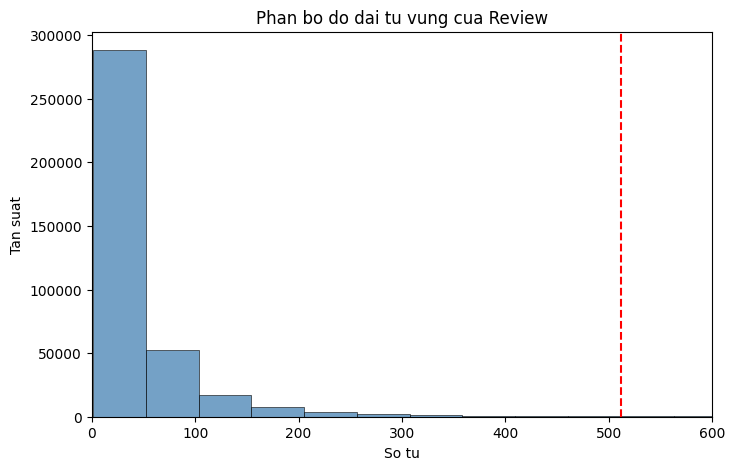

2. Xem tuong quan gia tien va so sao...


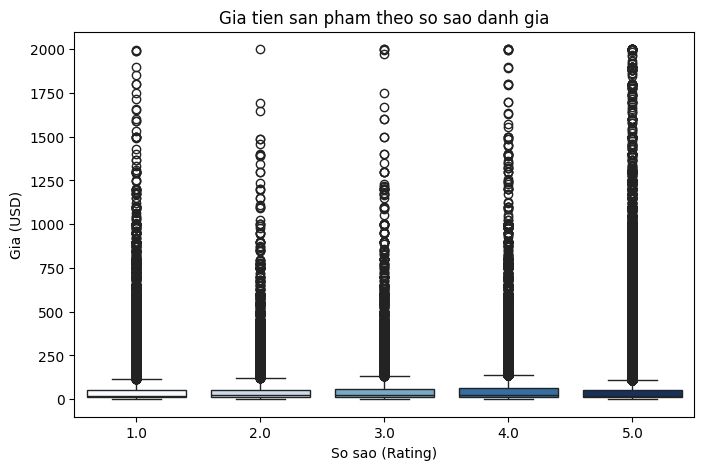

3. Trich xuat 10k san pham lam demo...
Xong het!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, split, size, regexp_extract, when, lit

# Khởi động Spark Session đã có từ cell trước
# sprk = SparkSession.builder \
#     .appName("EDA_BTL") \
#     .config("spark.driver.memory", "16g") \
#     .getOrCreate()

# Cấu hình đã được đặt ở cell trước đó, không cần đặt lại
# spark.conf.set("spark.sql.caseSensitive", "true")

# Duong dan file output dem qua
path = "/content/drive/MyDrive/MiningMassiveData/crawl_amazon_metadata/metadata/output/"

df_sp = spark.read.parquet(path + "san_pham.parquet")
df_dg = spark.read.parquet(path + "danh_gia.parquet")

print("Bat dau EDA...")

# ---------------------------------------------------------
# 1. Kiem tra do dai review de chuan bi cho model BERT (gioi han 512 tu)
# ---------------------------------------------------------
print("1. Tinh so tu cua cac review...")

# Them cot word_count bang cach cat chuoi theo dau cach
df_dg = df_dg.withColumn("word_count", size(split(col("text"), " ")))

# Lay mau 1% roi keo ve pandas de ve bieu do (tranh tran RAM)
df_len_sample = df_dg.select("word_count").sample(fraction=0.01, seed=42).toPandas()

plt.figure(figsize=(8, 5))
sns.histplot(df_len_sample['word_count'], bins=100, color='steelblue')
plt.title('Phan bo do dai tu vung cua Review')
plt.xlabel('So tu')
plt.ylabel('Tan suat')
plt.xlim(0, 600)
plt.axvline(x=512, color='red', linestyle='--') # Ke duong mau do o vi tri 512
plt.show()


# ---------------------------------------------------------
# 2. Xem muc gia co anh huong den so sao danh gia k
# ---------------------------------------------------------
print("2. Xem tuong quan gia tien va so sao...")

# Ep kieu cot price tu string sang float
# Modified: Use regexp_extract to get numeric part and handle empty strings before casting to float
df_sp = df_sp.withColumn(
    "price_float",
    when(regexp_extract(col("price"), '(\\d+\\.?\\d*)', 1) == '', lit(None))\
    .otherwise(regexp_extract(col("price"), '(\\d+\\.?\\d*)', 1))\
    .cast("float")
)

# Join 2 bang lai lay data_small
df_join = df_dg.join(df_sp, on="asin", how="inner")

# Loc cac san pham duoi 2000 do (bo may cai gia ao) va lay sample 2%
df_price_sample = df_join.filter(col("price_float").isNotNull()) \
                         .filter(col("price_float") < 2000) \
                         .select("rating", "price_float") \
                         .sample(fraction=0.02, seed=42).toPandas()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_price_sample, x='rating', y='price_float', hue='rating', palette='Blues', legend=False)
plt.title('Gia tien san pham theo so sao danh gia')
plt.xlabel('So sao (Rating)')
plt.ylabel('Gia (USD)')
plt.show()


# ---------------------------------------------------------
# 3. Chuan bi luon file 10k san pham de chieu nay chay model
# ---------------------------------------------------------
print("3. Trich xuat 10k san pham lam demo...")
# Loc sp khong bi thieu ten va thong so
df_demo = df_sp.filter(col("title").isNotNull() & col("details").isNotNull()).limit(10000)
df_demo.write.mode("overwrite").parquet(path + "demo_10k.parquet")

print("Xong het!")

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import torch
import faiss
from sentence_transformers import SentenceTransformer

# Dung @st.cache_resource de chi load model va data_small 1 lan duy nhat, tranh tran RAM
@st.cache_resource
def khoi_tao_he_thong():
    print("Dang khoi tao he thong...")
    # 1. Load lai ong thong dich vien
    model = SentenceTransformer('xlm-roberta-base')

    # 2. Load data_small va ma tran vector da lam toi qua
    path = "/content/drive/MyDrive/MiningMassiveData/crawl_amazon_metadata/metadata/output/"
    df_sp = pd.read_parquet(path + "demo_10k.parquet")

    # 🔥 ĐÃ SỬA LỖI: Thêm weights_only=False để PyTorch chịu load mảng Numpy
    vector_thong_so = torch.load(path + "item_embeddings.pt", weights_only=False)

    # Kiem tra xem co can chuyen tu Tensor sang Numpy khong (vi FAISS chi nhan Numpy)
    if isinstance(vector_thong_so, torch.Tensor):
        vector_sp = vector_thong_so.cpu().numpy()
    else:
        vector_sp = vector_thong_so # Neu da la numpy roi thi giu nguyen

    # FAISS chi nhan kieu du lieu numpy array
    vector_sp = torch.load(path + "item_embeddings.pt").cpu().numpy()

    # 3. Khoi tao Radar FAISS
    kich_thuoc_vector = vector_sp.shape[1] # Thong thuong la 768 chieu
    radar_faiss = faiss.IndexFlatL2(kich_thuoc_vector)
    radar_faiss.add(vector_sp) # Nap 10k vector vao radar

    return model, df_sp, radar_faiss

# ==========================================
# GIAO DIEN NGUOI DUNG
# ==========================================
st.title("🛒 He Thong Tim Kiem Lien Mien (Demo)")
st.write("Du lieu thuc nghiem: 10.000 san pham Amazon")

model, df_sp, radar_faiss = khoi_tao_he_thong()

# O nhap tu khoa tim kiem
tu_khoa = st.text_input("Nhap tu khoa ban muon tim (VD: tai nghe chong on, DAC/Amp Fiio, laptop choigame...):")

if tu_khoa:
    st.write(f"Đang quet radar cho: **{tu_khoa}**...")

    # Buoc A: Dich tu khoa thanh Vector
    vector_tu_khoa = model.encode([tu_khoa])

    # Buoc B: FAISS quet tim Top 5 san pham gan nhat
    khoang_cach, vi_tri = radar_faiss.search(vector_tu_khoa, 5)

    # Buoc C: In ket qua ra man hinh
    st.success("Tim thay cac ung vien sau:")
    for i in vi_tri[0]:
        san_pham = df_sp.iloc[i]
        with st.container():
            st.subheader(san_pham['title'])
            st.write(f"**Gia:** {san_pham.get('price', 'Dang cap nhat')}")
            # Chi in 200 ky tu dau tien cua details cho do dai
            chi_tiet = str(san_pham.get('details', ''))
            st.write(f"**Thong so:** {chi_tiet[:200]}...")
            st.write("---")

Overwriting app.py


In [ ]:
import urllib
import time

# Chay ngam Streamlit
!streamlit run app.py &>/content/logs.txt &

# Lay IP cua may chu Colab lam mat khau
print("⏳ Đang tao duong link...")
time.sleep(3)
ipv4 = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n")
print(f"🔑 MAT KHAU CUA BAN LA: {ipv4}")

# Mo cong localtunnel
!npx localtunnel --port 8501

⏳ Đang tao duong link...
🔑 MAT KHAU CUA BAN LA: 34.81.26.55
⠙your url is: https://short-phones-crash.loca.lt
